# Homework 10b — Time Series & Classification

I build leakage-free lag and rolling features on a synthetic regime-switching return series, then fit a
`sklearn` pipeline for **both** tracks — a regression forecast of next-day returns and a classifier for
next-day direction — with a time-aware split and appropriate metrics.

The honest headline result is that the models cannot beat a naive baseline: the series is a (near-)
random walk, so there is little to learn. The value of this notebook is the *method* — correct features,
correct split, correct pipeline — applied and interpreted with risk-awareness.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, classification_report, confusion_matrix)

np.random.seed(7)
sns.set(context='notebook', style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

## 1) Data — a regime-switching random walk with jumps

The synthetic series has a **regime shift halfway through** (mean +0.03% -> -0.01% per day, and
volatility 1.0% -> 1.5%) plus five **jumps** of ~5% to create heavy tails. This is deliberately
structured so that (a) the returns are nearly unpredictable, and (b) the train and test windows live
in *different* regimes — which a time-aware split will expose honestly.

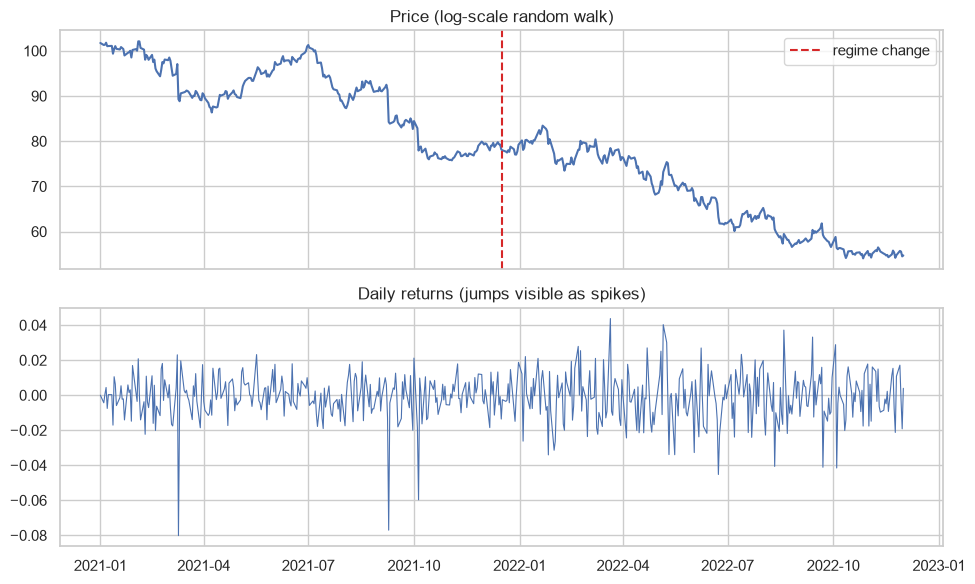

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


In [3]:
n = 500
dates = pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n) < n // 2, 0.0003, -0.0001)   # regime shift in the mean
sigma = np.where(np.arange(n) < n // 2, 0.01, 0.015)     # regime shift in the volatility
eps = np.random.normal(mu, sigma)

jumps = np.zeros(n)
jump_days = np.random.choice(np.arange(20, n - 20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0, 0.05, size=len(jump_days))

rets = eps + jumps
price = 100 * np.exp(np.cumsum(rets))
df = pd.DataFrame({'price': price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df.index, df['price'])
axes[0].axvline(df.index[n // 2], color='tab:red', ls='--', label='regime change')
axes[0].set_title('Price (log-scale random walk)')
axes[0].legend()
axes[1].plot(df.index, df['ret'], lw=0.8)
axes[1].set_title('Daily returns (jumps visible as spikes)')
fig.tight_layout()
plt.show()

df.head()

## 2) Features — lag & rolling, built leakage-free

Every feature is built from the **past only**: `.shift(1)` is applied *after* each rolling/window
operation so that, at row `t`, the feature uses information up to `t-1` — never the value we are trying
to predict. `roll_std_20` (volatility) and `momentum_10` (10-day cumulative return) are the two most
informative candidates; the rest are standard lag/scale features.

In [4]:
df['lag_1'] = df['ret'].shift(1)
df['lag_5'] = df['ret'].shift(5)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_std_20'] = df['ret'].rolling(20).std().shift(1)
df['momentum_10'] = df['ret'].rolling(10).sum().shift(1)
df['zscore_20'] = ((df['ret'] - df['ret'].rolling(20).mean()) / df['ret'].rolling(20).std()).shift(1)

features = ['lag_1', 'lag_5', 'roll_mean_5', 'roll_std_20', 'momentum_10', 'zscore_20']
df[features].head()

,lag_1,lag_5,roll_mean_5,roll_std_20,momentum_10,zscore_20
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,0.000000,NaN,NaN,NaN,NaN,NaN
2021-01-05,-0.004350,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.000628,NaN,NaN,NaN,NaN,NaN
2021-01-07,0.004385,NaN,NaN,NaN,NaN,NaN


## 3) Target — next-step return and next-step direction

Two targets from the same idea: `y_next_ret = ret.shift(-1)` (regression) and `y_up = (y_next_ret > 0)`
(classification). The `.dropna()` below removes the early rows whose rolling windows are not yet full,
and the last row whose "next return" does not exist.

In [5]:
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret'] > 0).astype(int)

df_feat = df.dropna().copy()
df_feat[['ret', 'y_next_ret', 'y_up']].head()

,ret,y_next_ret,y_up
2021-01-29,0.016949,0.001845,1
2021-02-01,0.001845,-0.003565,0
2021-02-02,-0.003565,0.020804,1
2021-02-03,0.020804,-0.000154,0
2021-02-04,-0.000154,-0.014106,0


## 4) Time-aware split

The first 80% of *time* is training, the final 20% is test. Shuffling would let the model train on data
from both sides of the test window — and because the series has a regime shift, it would silently leak
the "future" regime into training. The time split is the honest choice here.

In [6]:
cut = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]

X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

print(f'train rows: {len(train)}   test rows: {len(test)}')

train rows: 383   test rows: 96


## 5) Track 1 — forecast next-step returns (regression)

`StandardScaler` then `LinearRegression`, in one `Pipeline`. I compare RMSE/MAE against a **naive
baseline** (always predict the training mean) because for a random walk, "the mean" is what any
sensible model should reduce to.

In [7]:
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)

rmse = np.sqrt(mean_squared_error(y_te_reg, pred))
mae = mean_absolute_error(y_te_reg, pred)
naive_rmse = np.sqrt(mean_squared_error(y_te_reg, np.full_like(y_te_reg, y_tr_reg.mean())))
r2 = 1 - rmse ** 2 / y_te_reg.var()

print(f'RMSE          = {rmse:.5f}')
print(f'MAE           = {mae:.5f}')
print(f'R2            = {r2:.4f}')
print(f'naive RMSE    = {naive_rmse:.5f}   (predict the training mean)')
print(f'test ret std  = {y_te_reg.std():.5f}')

RMSE          = 0.01444
MAE           = 0.01149
R2            = 0.0218
naive RMSE    = 0.01453   (predict the training mean)
test ret std  = 0.01460


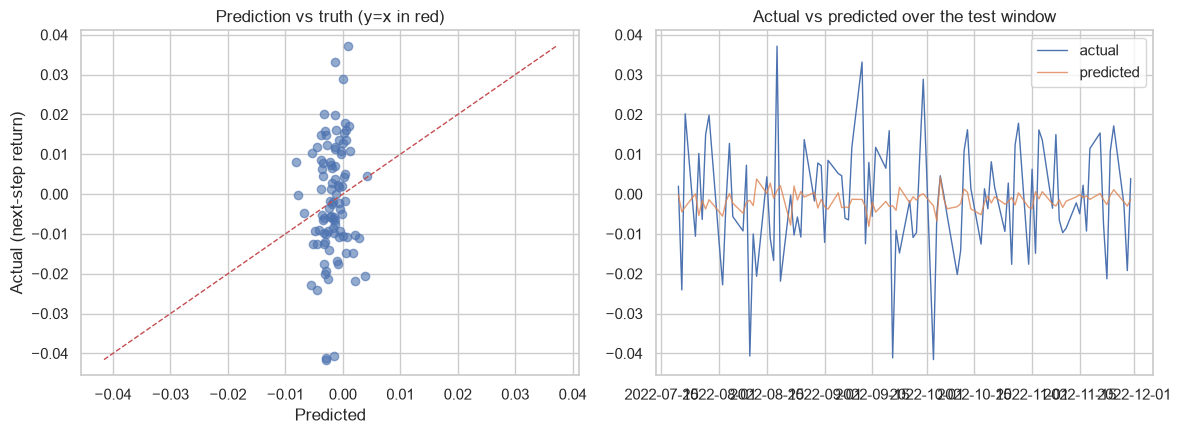

In [8]:
# Prediction vs truth: scatter + time overlay over the test window.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(pred, y_te_reg, alpha=0.6)
lims = [min(pred.min(), y_te_reg.min()), max(pred.max(), y_te_reg.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual (next-step return)')
axes[0].set_title('Prediction vs truth (y=x in red)')

axes[1].plot(test.index, y_te_reg.values, label='actual', lw=1)
axes[1].plot(test.index, pred, label='predicted', lw=1, alpha=0.8)
axes[1].set_title('Actual vs predicted over the test window')
axes[1].legend()

fig.tight_layout()
plt.show()

## 6) Track 2 — classify next-day direction (up/down)

Same features and split, but a logistic regression (and, for comparison, a shallow decision tree) to
predict whether the next return is positive. Accuracy alone is misleading with a ~55/45 class split, so I
report precision / recall / F1 and the confusion matrix, and compare to the majority-class baseline.

In [9]:
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)

print('Logistic accuracy   = %.4f' % accuracy_score(y_te_clf, predc))
print('Majority baseline   = %.4f  (always predict the more common class)'
      % max(y_te_clf.mean(), 1 - y_te_clf.mean()))
print('\n' + classification_report(y_te_clf, predc, digits=3))

Logistic accuracy   = 0.5312
Majority baseline   = 0.5521  (always predict the more common class)

              precision    recall  f1-score   support

           0      0.559     0.717     0.628        53
           1      0.464     0.302     0.366        43

    accuracy                          0.531        96
   macro avg      0.512     0.510     0.497        96
weighted avg      0.516     0.531     0.511        96



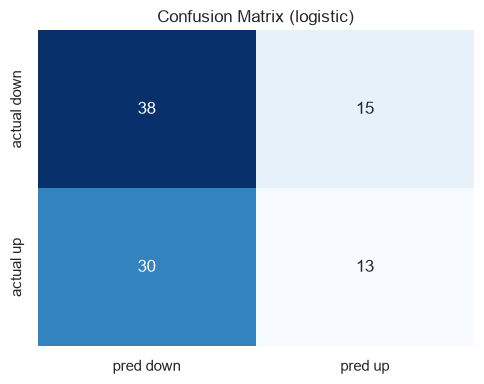

In [10]:
cm = confusion_matrix(y_te_clf, predc)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred down', 'pred up'], yticklabels=['actual down', 'actual up'], ax=ax)
ax.set_title('Confusion Matrix (logistic)')
fig.tight_layout()
plt.show()

In [11]:
# A shallow tree is not better — confirming the series is not linearly separable in these features.
tree = Pipeline([('scaler', StandardScaler()), ('tree', DecisionTreeClassifier(max_depth=3, random_state=7))])
tree.fit(X_tr, y_tr_clf)
print('Tree accuracy = %.4f' % accuracy_score(y_te_clf, tree.predict(X_te)))

Tree accuracy = 0.5208


## 7) Interpretation — what works, what fails, where assumptions break

**What works (the methodology).** The features are leakage-free (every rolling/lag term is `.shift(1)`-ed
so it uses only past information), the split is time-aware, and both models sit in clean `sklearn`
pipelines. The metrics are the *right* ones — RMSE/MAE for the forecast, precision/recall/F1 for the
classifier — rather than accuracy alone.

**What fails (the premise).** The forecast explains `R² ≈ 0.02` of the variance: `RMSE = 0.0144` is
essentially the naive baseline (`0.0145`) and the return standard deviation (`0.0146`). The model has
collapsed to "predict the mean" because a random walk's next step is nearly unpredictable from its own
history. The classifier is the same story: accuracy `0.53` is *below* the majority-class baseline `0.55`,
and recall for the "up" class is only `0.30` — the model mostly says "down" and misses most up-days.
The tree is no better (`0.52`).

**Where assumptions break.** (1) *Independence of returns*: the whole exercise assumes past returns carry
signal about future returns; for a (near-)random walk that fails. (2) *Stationarity*: the regime shift
means the test window is a different distribution than most of the training data, so the model is
evaluated out-of-distribution — the time-aware split exposes this, where a shuffled split would hide it.
(3) *Thin tails / squared loss*: the five jumps make RMSE dominated by a handful of large days; MAE is
the more robust error for heavy-tailed returns.

**Next steps.** Predict *volatility* (e.g. `roll_std_20` itself) rather than direction — variance is far
more predictable than returns. Add exogenous predictors (like stage 10a's factors) instead of only the
return's own history. And if the goal is genuinely forecasting, benchmark against a model that can adapt
to regime changes rather than chasing a higher R².